<a href="https://colab.research.google.com/github/Thranduil-reigns/she-codes-work/blob/main/Medicine%20Expiry%20Checker%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install easyocr opencv-python-headless matplotlib


In [ ]:
import cv2
import easyocr
import matplotlib.pyplot as plt
import re
from datetime import datetime


In [ ]:
reader = easyocr.Reader(['en'])
image_path = "expiry.jpeg"
results = reader.readtext(image_path)
for (bbox, text, prob) in results:
    print(f"Detected text: {text} (Confidence: {prob:.2f})")

Detected text: 9/11/16 (Confidence: 0.37)
Detected text: 9/11/18 (Confidence: 0.52)


In [ ]:
def extract_expiry(texts):
    patterns = [
        r"(0[1-9]|1[0-2])[/\-](\d{2}|\d{4})",        # 03/25 or 03/2025
        r"(\d{2})[/\-](0[1-9]|1[0-2])[/\-](\d{4})", # 15/03/2025
        r"(JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[/\- ](\d{2,4})"
    ]

    for text in texts:
        for p in patterns:
            match = re.search(p, text.upper())
            if match:
                return match.group(0)
    return None

detected_texts = [text for (_, text, _) in results]
expiry_date = extract_expiry(detected_texts)
print("Extracted Expiry Date:", expiry_date)

Extracted Expiry Date: 11/16


In [ ]:
def check_expiry(expiry_date):
    try:
       if re.match(r"(0[1-9]|1[0-2])/\d{2}$", expiry_date):
            exp = datetime.strptime(expiry_date, "%m/%y")
       elif re.match(r"(0[1-9]|1[0-2])/\d{4}$", expiry_date):
            exp = datetime.strptime(expiry_date, "%m/%Y")
       elif re.match(r"\d{2}/(0[1-9]|1[0-2])/\d{4}$", expiry_date):
            exp = datetime.strptime(expiry_date, "%d/%m/%Y")
       else:
            return "Could not parse date format"

       today = datetime.now()
       return "Expired ❌" if exp < today else "Valid ✅"

    except Exception as e:
        return f"Error: {e}"

if expiry_date:
    print("Medicine Status:", check_expiry(expiry_date))
else:
    print("No expiry date detected.")

Medicine Status: Expired ❌


In [ ]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)


Saving medicine.jpeg to medicine.jpeg
Uploaded file: medicine.jpeg


In [ ]:
import easyocr
reader = easyocr.Reader(['en'], gpu=True)
results = reader.readtext(filename)
for (bbox, text, prob) in results:
    print(f"Detected text: {text} (Confidence: {prob:.2f})")

Detected text: 83 3883 (Confidence: 0.21)
Detected text: r (Confidence: 0.05)


In [ ]:
import re

print("\n--- Possible Expiry Information ---")
for (bbox, text, prob) in results:
    clean_text = text.lower().strip()
if re.search(r"(exp|expiry|use\s*by|best\s*before|valid\s*till|bbe|\bm\b|\be\b|mfg|mf)", clean_text):
        print(f"Detected info: {text} (Confidence: {prob:.2f})")




--- Possible Expiry Information ---


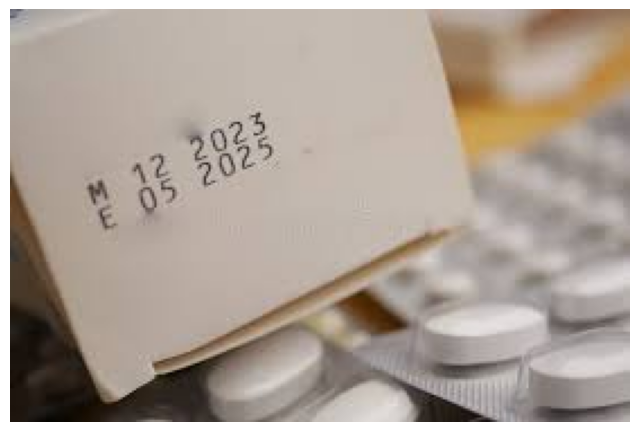

In [ ]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread(filename)
for (bbox, text, prob) in results:
    if any(keyword in text.lower() for keyword in ["exp", "expiry", "use by", "best before"]):
      top_left = tuple([int(val) for val in bbox[0]])
      bottom_right = tuple([int(val) for val in bbox[2]])
      cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
      cv2.putText(image, text, (top_left[0], top_left[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [4]:
!apt-get install -y libzbar0
!pip install pyzbar pillow

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-double3
  libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0 libjxr-tools libjxr0
  liblqr-1-0 libmagickcore-6.q16-6 libmagickcore-6.q16-6-extra
  libmagickwand-6.q16-6 libv4l-0 libv4lconvert0 libwmflite-0.2-7 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x libfftw3-bin libfftw3-dev inkscape poppler-utils
  fonts-japanese-mincho | fonts-ipafont-mincho fonts-japanese-gothic
  | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-uming fonts-nanum
The following NEW packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-

In [8]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)


Saving qr code.png to qr code.png
Uploaded file: qr code.png



--- Barcode / QR Code Detection ---
Detected QRCODE: https://hub.medsoncue.com/qrc/sqROO1580ksj-516721364/r_151584


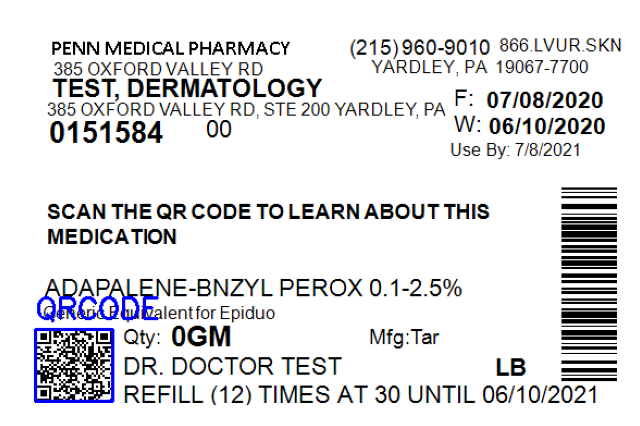

In [9]:
import cv2
from pyzbar.pyzbar import decode
from PIL import Image
import matplotlib.pyplot as plt

img = cv2.imread(filename)
barcodes = decode(Image.open(filename))

print("\n--- Barcode / QR Code Detection ---")
if barcodes:
    for barcode in barcodes:
        barcode_data = barcode.data.decode("utf-8")  # Extract data
        barcode_type = barcode.type  # Type (e.g., QRCODE, CODE128)
        print(f"Detected {barcode_type}: {barcode_data}")
        (x, y, w, h) = barcode.rect
        cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(img, barcode_type, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
else:
    print("No barcode/QR code detected.")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [17]:
!pip install easyocr
import easyocr
import re
reader = easyocr.Reader(['en'], gpu=True)
results = reader.readtext(filename)
print("\n--- Detected Expiry / Manufacturing Info ---")
expiry_found = False
for (bbox, text, prob) in results:
    clean_text = text.lower().strip()
    if re.search(r"(exp|expiry|use\s*by|best\s*before|valid\s*till|bbe|\bm\b|\be\b|mfg|mf)", clean_text):
        expiry_found = True
        print(f"{text} (Confidence: {prob:.2f})")
        # Draw rectangle around detected text
        top_left = tuple([int(val) for val in bbox[0]])
        bottom_right = tuple([int(val) for val in bbox[2]])
        img = cv2.imread(filename)
        cv2.rectangle(img, top_left, bottom_right, (0, 255, 0), 2)
        cv2.putText(img, text, (top_left[0], top_left[1] - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
if not expiry_found:
    print("No expiry/manufacturing info detected.")


--- Detected Expiry / Manufacturing Info ---
Use By: 7/8/2021 (Confidence: 0.97)
Mfg: Tar (Confidence: 0.90)


In [19]:
from datetime import datetime

def extract_expiry_date(text):
    # Match formats like MM/YYYY, M/YYYY, YYYY-MM, YYYY/MM
    match = re.search(r'(\d{1,2}[/-]\d{2,4}|\d{4}[/-]\d{1,2})', text)
    if match:
        return match.group()
    return None

def parse_date(date_str):
    for fmt in ("%m/%Y", "%m-%Y", "%Y-%m", "%Y/%m"):
        try:
            return datetime.strptime(date_str, fmt)
        except:
            continue
    return None

# Helpline info
helpline = "For expired medicine guidance, call: +254 123 456 789 (Pharmacy Helpline)"

today = datetime.today()
expiry_found = False

for (bbox, text, prob) in results:
    expiry_text = extract_expiry_date(text)
    if expiry_text:
        expiry_found = True
        expiry_date = parse_date(expiry_text)
        if expiry_date:
            if expiry_date < today:
                print(f"Medicine is EXPIRED! (Expiry: {expiry_text})")
                print(helpline)
            else:
                print(f"Medicine is NOT expired. (Expiry: {expiry_text})")

if not expiry_found:
    print("No expiry date could be extracted.")



Medicine is EXPIRED! (Expiry: 8/2021)
For expired medicine guidance, call: +254 123 456 789 (Pharmacy Helpline)
